## Testing relative / absolute time

In [1]:
from maelzel.core import *

Chain([4C:1/2♩, 4D:1♩, Chain([4E:1♩:symbols=[Text(text='abs. offset=6', placement='above')], 4F:2♩], offset=5)], offset=1)
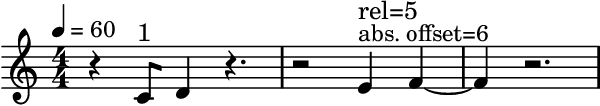

In [2]:
chain2 = Chain(["4E:1", "4F:2"], offset=5, label='rel=5')
ch = Chain(["4C:0.5", "4D", chain2], offset=1, label='1')
chain2[0].addText(f'abs. offset={chain2.absOffset()}')
ch


In [3]:
ch.quantizedScore().dump()

Part #0
  Measure #0
    Timesig: 4/4, beats: 1, 1, 1, 1 (𝅘𝅥=60)
    Node ratio: ¹⁄₁, offset=0, end=4, dur=4, symbolicdur=4 ⌈
      r⋮1♩⋮0:1: 1 = 𝅘𝅥
      4C!⋮1/2♩⋮1:1.5⋮attachments=[Text('1', fontsize=9.0, placement=above)]: 1/2 = 𝅘𝅥𝅮
      4D!⋮1♩⋮1.5:2.5: 1 = 𝅘𝅥
      r⋮3/2♩⋮2.5:4: 3/2 = 𝅘𝅥∙
    ⌋
  Measure #1
    Timesig: 4/4, beats: 1, 1, 1, 1
    Node ratio: ¹⁄₁, offset=0, end=4, dur=4, symbolicdur=4 ⌈
      r⋮2♩⋮0:2: 2 = 𝅗𝅥
      4E!⋮1♩⋮2:3⋮attachments=[Text('abs. offset=6', placement=above), Text('rel=5',
        fontsize=9.0, placement=above)]: 1 = 𝅘𝅥
      4F!~⋮1♩⋮3:4: 1 = 𝅘𝅥
    ⌋
  Measure #2
    Timesig: 4/4, beats: 1, 1, 1, 1
    Node ratio: ¹⁄₁, offset=0, end=4, dur=4, symbolicdur=4 ⌈
      ~4F!⋮1♩⋮0:1: 1 = 𝅘𝅥
      r⋮3♩⋮1:4: 3 = 𝅗𝅥∙
    ⌋


Chain([4C:1/2♩:offset=1, 4D:1♩, Chain([4E:1♩:symbols=[Text(text='absoffset=5', placement='above')], 4F:2♩], offset=5)])
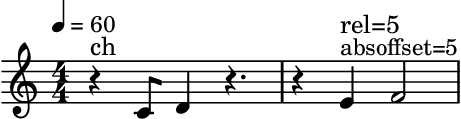

In [4]:
chain2 = Chain(["4E:1", "4F:2"], offset=5, label='rel=5')
ch = Chain(["4C:0.5:offset=1", "4D", chain2], label='ch')
chain2[0].addText(f'absoffset={chain2.absOffset()}')
ch


In [5]:
ch.dump()

In [6]:
ch.flatEvents()


[4C:1/2♩:offset=1,
 4D:1♩:offset=1.5,
 4E:1♩:offset=5:symbols=[Text(text='absoffset=5', placement='above')],
 4F:2♩:offset=6]

In [7]:
ch.flat().dump()

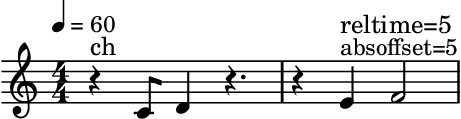

Chain([4C:1/2♩:offset=1, 4D:1♩:offset=1.5, 4E:1♩:offset=5:symbols=[Text(text='absoffset=5', placement='above')], 4F:2♩:offset=6])
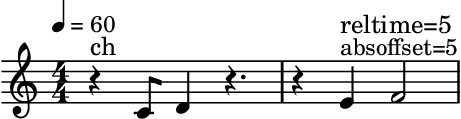

In [8]:
chain2 = Chain(["4E:1", "4F:2"], offset=5, label='reltime=5')
ch = Chain(["4C:0.5:offset=1", "4D", chain2], label='ch')
chain2[0].addText(f'absoffset={chain2.absOffset()}')
ch

ch.show()
flat = ch.flat()
flat

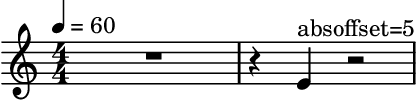

True

In [9]:
n = ch[2][0]
n.show()
n.offset is None

In [10]:
n.relOffset()

Fraction(0, 1)

In [11]:
n.absOffset()

Fraction(5, 1)

Chain([4C:1/2♩:offset=1, 4D:1♩:offset=1.5, 4E:1♩:offset=5:symbols=[Text(text='absoffset=5', placement='above')], 4F:2♩:offset=6])
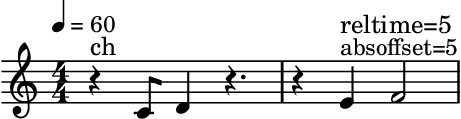

In [12]:
ch2 = ch.flat()
ch2.dump()
ch2

Chain([R:1♩, 4C:1/2♩, 4D:1♩, R:5/2♩, 4E:1♩:symbols=[Text(text='absoffset=5', placement='above')], 4F:2♩])
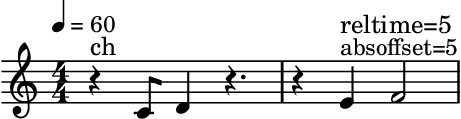

In [13]:
ch2.fillGaps()
ch2.removeRedundantOffsets()
ch2.dump()
ch2

In [14]:
from maelzel.core import *

In [15]:
ScoreStruct('7/8').activate()

Meas. Index,Timesig,Tempo,Label,Rehearsal,Barline,Beats
0,7/8,𝅘𝅥=60,,,,7×𝅘𝅥𝅮
...,,,,,,


R:2♩:offset=3.5
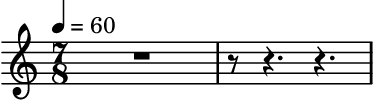

In [16]:
r = Rest(2, offset=3.5)
r

In [17]:
r.quantizedScore()

Part #0
  Measure #0
    Timesig: 7/8, beats: 1/2, 1/2, 1/2, 1/2, 1/2, 1/2, 1/2 (𝅘𝅥=60)
    Node ratio: ¹⁄₁, offset=0, end=7/2, dur=7/2, symbolicdur=7/2 ⌈
      r⋮7/2♩⋮0:3.5: 7/2 = 𝅗𝅥∙∙
    ⌋
  Measure #1
    Timesig: 7/8, beats: 1/2, 1/2, 1/2, 1/2, 1/2, 1/2, 1/2
    Node ratio: ¹⁄₁, offset=0, end=7/2, dur=7/2, symbolicdur=7/2 ⌈
      r⋮1/2♩⋮0:0.5⋮attachments=[Breath(horizontalPlacement=post, placement=above)]: 1/2 = 𝅘𝅥𝅮
      r⋮3/2♩⋮0.5:2: 3/2 = 𝅘𝅥∙
      r⋮3/2♩⋮2:3.5: 3/2 = 𝅘𝅥∙
    ⌋

In [19]:
r._scoringEvents()

[r⋮2♩⋮3.5:5.5]